# Tips Prediction Using Machine Learning Regression Models

## Project Overview

This project aims to predict the amount of tip left by a restaurant customer using supervised machine learning regression algorithms.

Rather than relying on a single model, this notebook develops, evaluates, and compares multiple regression techniques to determine the most suitable algorithm for predicting tip amounts.

The project follows a complete end-to-end machine learning workflow, beginning with business understanding and data exploration, followed by preprocessing, feature engineering, model development, hyperparameter optimization, evaluation, and deployment preparation.

The implemented regression models include:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

Each model will be evaluated using several regression metrics to provide a comprehensive comparison of predictive performance.

The final section of this project exports the best-performing model to be deployed in a Streamlit web application.

# Business Understanding

## Problem Statement

Restaurant owners often seek to understand the factors that influence customer tipping behavior. Predicting the expected tip amount can provide valuable insights into customer spending patterns, employee performance analysis, revenue estimation, and service optimization.

Since the tip amount is a continuous numerical value rather than a categorical outcome, this problem is naturally formulated as a supervised regression task.

The objective of this project is to develop an accurate machine learning model capable of estimating customer tips based on restaurant-related attributes such as:

- Total bill
- Customer gender
- Smoking status
- Day of the week
- Time of the meal
- Party size

## Business Objectives

The primary objectives of this project are:

- Estimate customer tip amounts accurately.
- Compare multiple regression algorithms.
- Identify the most influential factors affecting tipping behavior.
- Build an interpretable and reusable prediction pipeline.
- Prepare the trained model for deployment in a production-ready Streamlit application.

## Machine Learning Objective

Train several regression models and determine the best-performing model using multiple evaluation metrics rather than relying on a single score.

The final model will be selected based on its ability to generalize well on unseen data while maintaining low prediction errors.

# Environment Setup

Before performing any analysis, all required libraries are imported.

The notebook uses common Python libraries for:

- Data manipulation
- Numerical computation
- Data visualization
- Machine learning
- Hyperparameter optimization
- Model serialization

Keeping all imports in a dedicated section improves notebook readability and reproducibility.

In [1]:
# ============================
# Standard Library
# ============================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ============================
# Data Manipulation
# ============================

import numpy as np
import pandas as pd

# ============================
# Data Visualization
# ============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

# ============================
# Machine Learning
# ============================

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================
# Regression Models
# ============================

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# ============================
# Model Persistence
# ============================

import joblib

# Data Loading

The first step in every machine learning project is loading the dataset and validating its structure.

During this phase we will:

- Locate the dataset.
- Read the CSV file.
- Display the dataset dimensions.
- Inspect the first observations.
- Review data types.
- Verify that the dataset has been loaded successfully before proceeding with analysis.

In [3]:
# Load Dataset

df = sns.load_dataset("tips")

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Data Understanding

Understanding the dataset is an essential step before performing any preprocessing or modeling.

In this phase, we will examine the dataset from multiple perspectives to ensure that it is complete, clean, and suitable for regression modeling.

The analysis includes:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Descriptive statistics
- Unique values
- Memory usage

These checks help identify potential data quality issues that may affect the performance of machine learning models.

In [4]:
# Dataset Shape

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 244
Number of Columns : 7


In [5]:
# Display First Rows

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
# Display Last Rows

df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [7]:
# Data Types

df.dtypes.to_frame("Data Type")

,Data Type
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


In [8]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [9]:
# Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing_values

,Missing Values,Percentage
total_bill,0,0.0
tip,0,0.0
sex,0,0.0
smoker,0,0.0
day,0,0.0
time,0,0.0
size,0,0.0


In [10]:
# Duplicate Records

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 1


In [11]:
# Unique Values

unique_values = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

unique_values

,Unique Values,Data Type
total_bill,229,float64
tip,123,float64
sex,2,category
smoker,2,category
day,4,category
time,2,category
size,6,int64


In [12]:
# Memory Usage

memory = df.memory_usage(deep=True) / 1024

memory.to_frame("Memory (KB)")

,Memory (KB)
Index,0.128906
total_bill,1.906250
tip,1.906250
sex,0.369141
smoker,0.364258
day,0.450195
time,0.370117
size,1.906250


# Data Quality Assessment

Based on the previous inspection:

- The dataset contains a manageable number of observations.
- Numerical and categorical variables are clearly separated.
- Missing values will be verified before preprocessing.
- Duplicate records will be investigated.
- Data types appear appropriate for machine learning.

Overall, the dataset structure is simple and suitable for regression analysis.

# Data Cleaning

Before exploring the data visually, basic cleaning operations will be performed.

The objectives are:

- Remove duplicate observations.
- Confirm the absence of missing values.
- Reset the dataframe index.
- Create a clean copy for the remaining analysis.

These steps ensure that subsequent analyses are performed on reliable and consistent data.

In [13]:
# Remove Duplicates

print("Shape Before :", df.shape)

df = df.drop_duplicates()

df.reset_index(drop=True, inplace=True)

print("Shape After  :", df.shape)

Shape Before : (244, 7)
Shape After  : (243, 7)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps reveal patterns, relationships, distributions, and anomalies within the dataset.

Since the target variable is numerical, understanding how each feature influences the tip amount is particularly important.

The analysis will cover:

- Univariate Analysis
- Bivariate Analysis
- Target Analysis
- Numerical Relationships
- Categorical Relationships
- Correlation Analysis
- Outlier Detection

# Univariate Analysis

The first step in EDA is to understand the distribution of every variable individually.

This helps identify:

- Central tendency
- Spread
- Skewness
- Potential outliers
- Data distribution shape

In [14]:
numerical_features = df.select_dtypes(include=np.number).columns

numerical_features

Index(['total_bill', 'tip', 'size'], dtype='str')

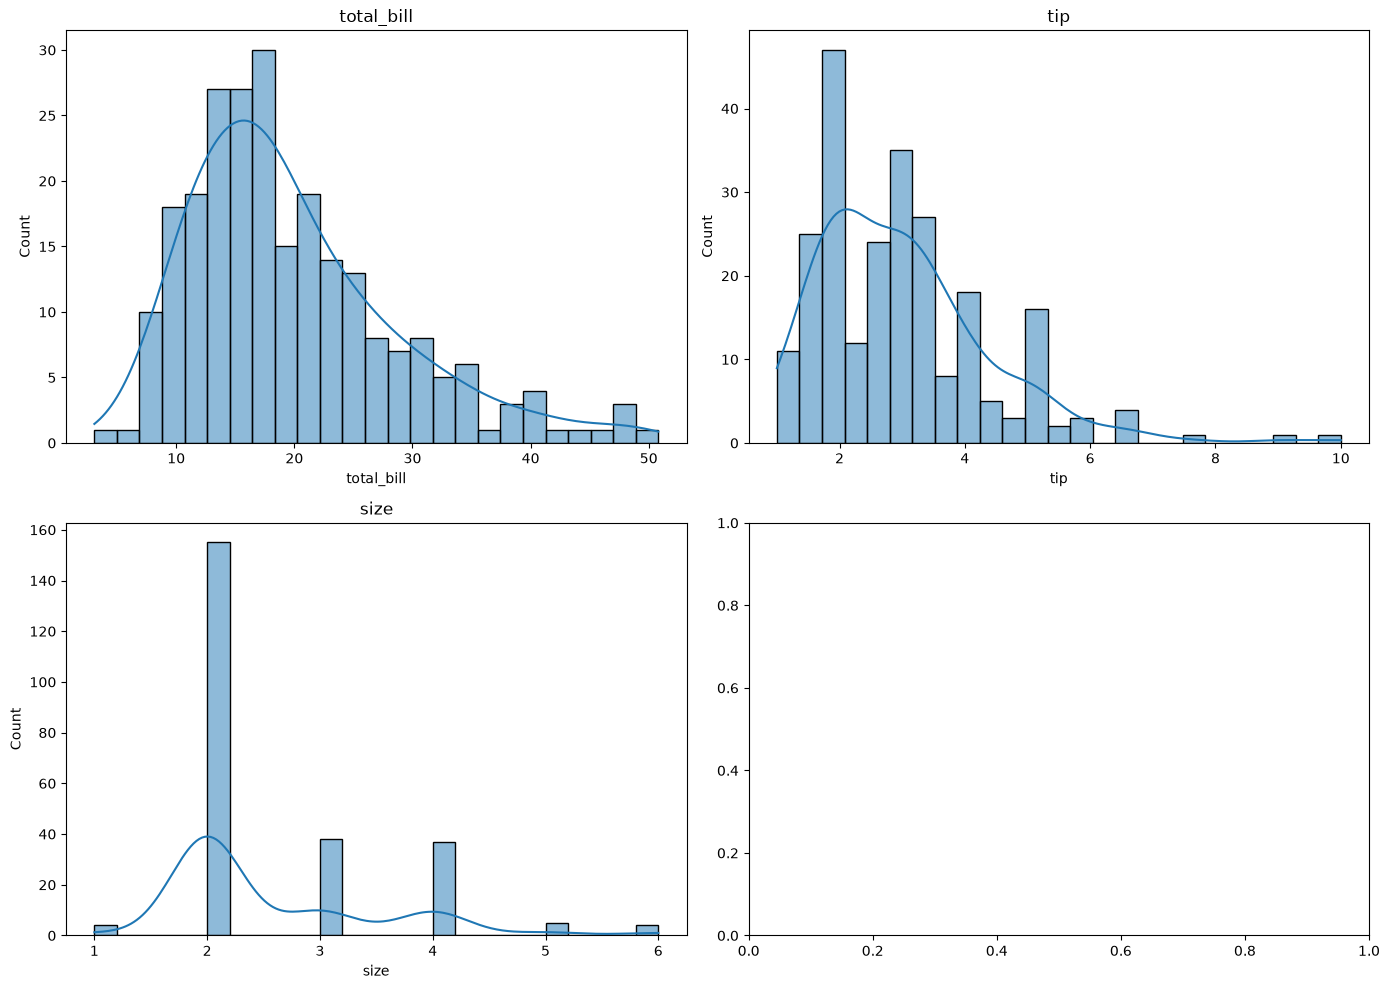

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for ax, column in zip(axes, numerical_features):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=25,
        ax=ax
    )

    ax.set_title(column)

plt.tight_layout()
plt.show()

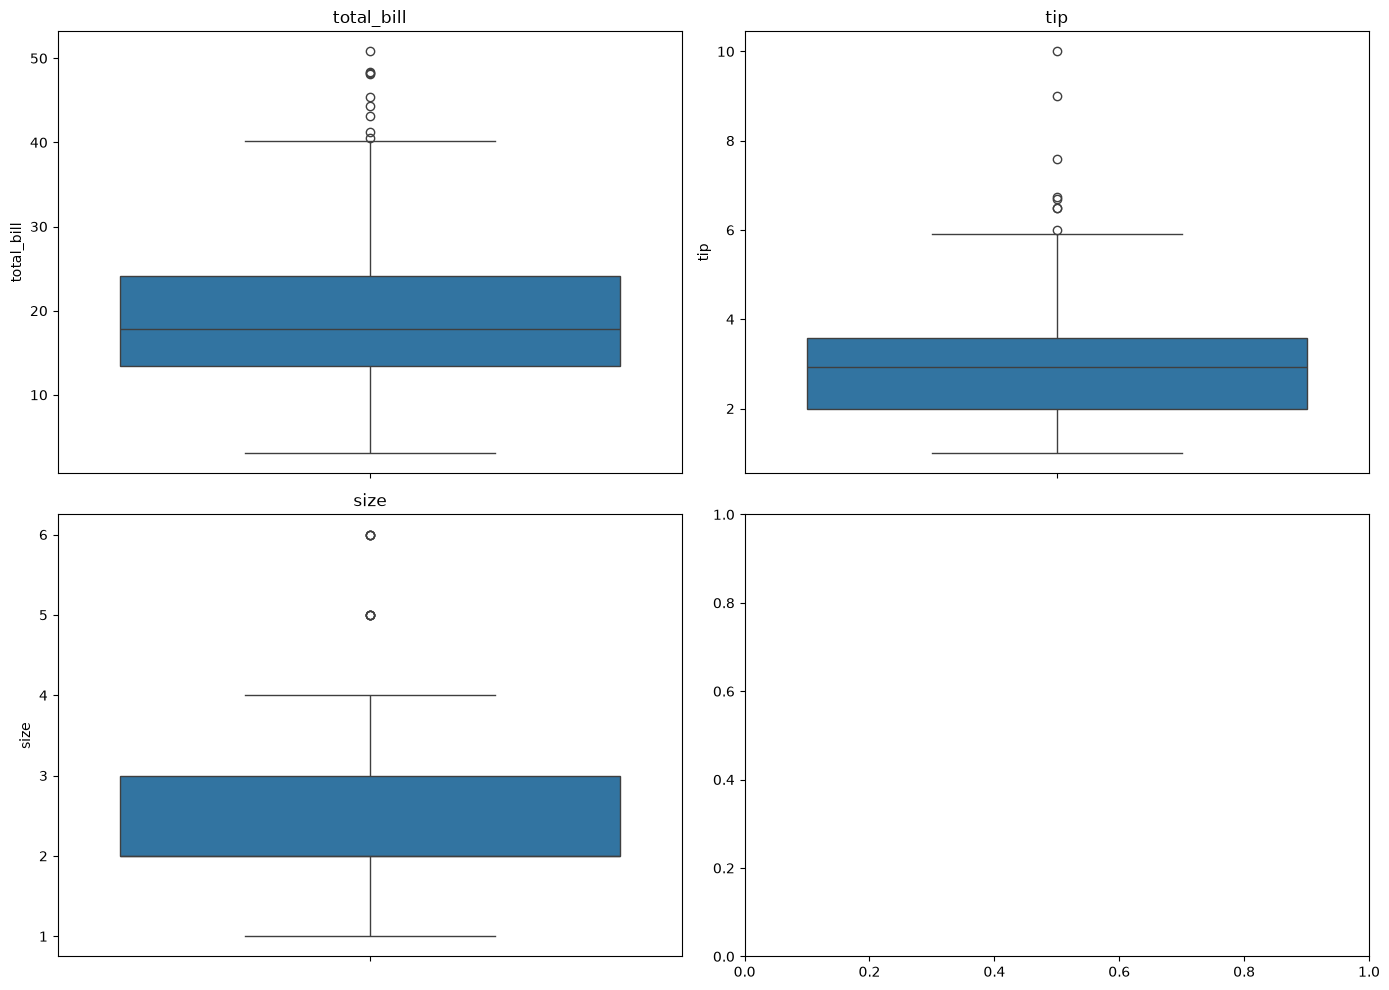

In [16]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

axes = axes.flatten()

for ax, column in zip(axes, numerical_features):

    sns.boxplot(
        data=df,
        y=column,
        ax=ax
    )

    ax.set_title(column)

plt.tight_layout()

plt.show()

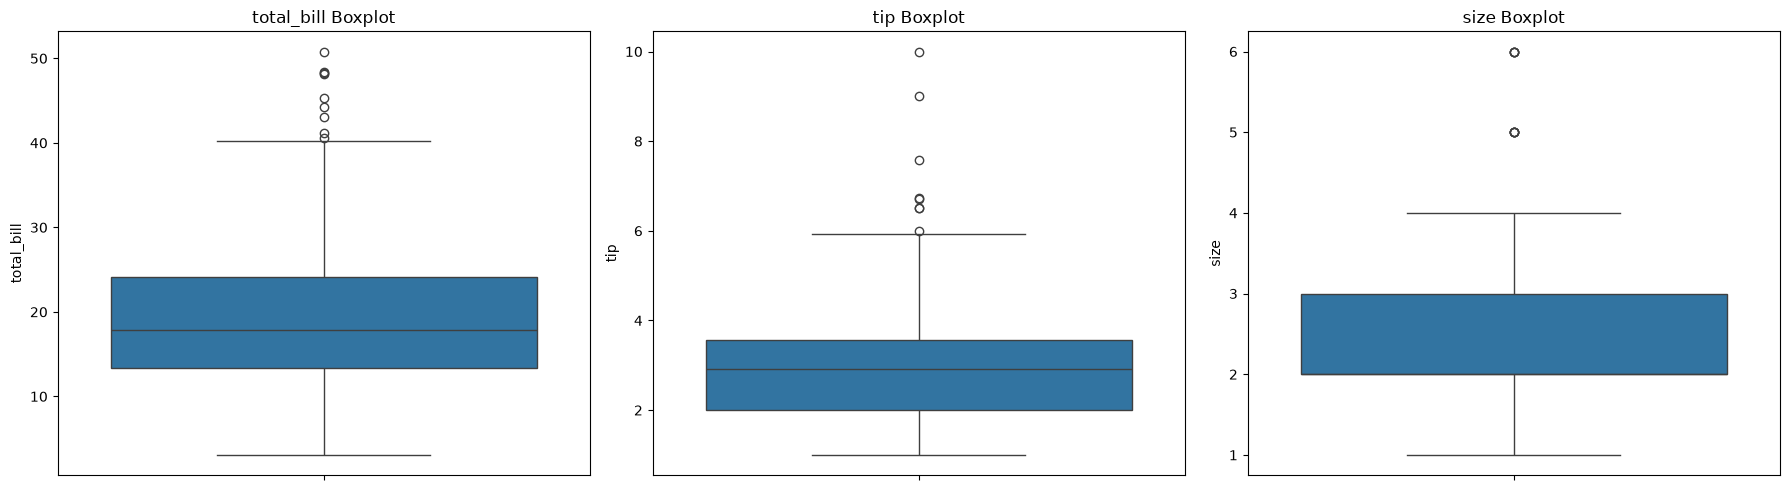

Shape Before Removing Outliers: (243, 7)
Shape After Removing Outliers : (227, 7)


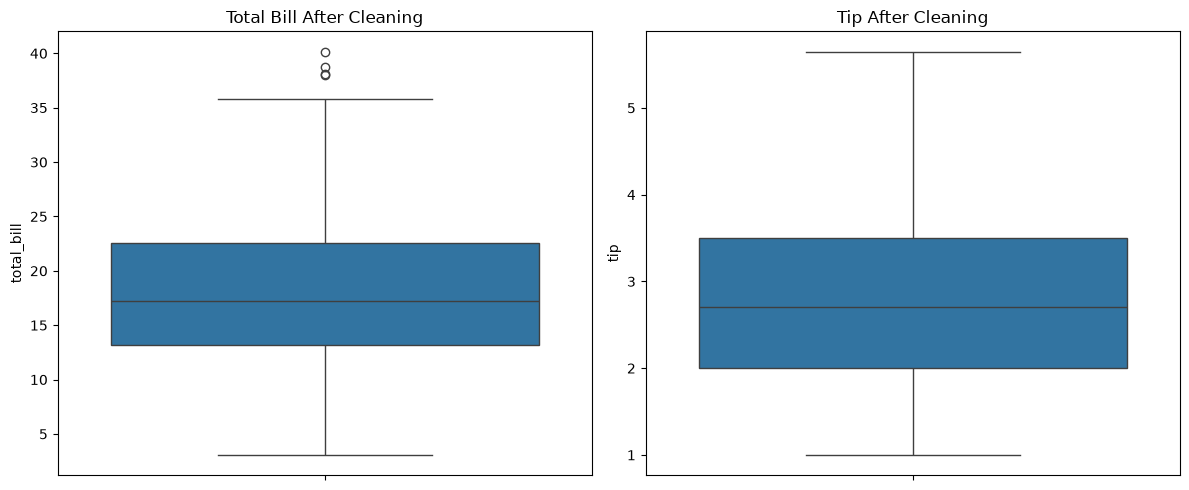

In [18]:

# ============================
# Outlier Detection
# ============================

numerical_features = ["total_bill", "tip", "size"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, numerical_features):
    sns.boxplot(data=df, y=feature, ax=ax)
    ax.set_title(f"{feature} Boxplot")

plt.tight_layout()
plt.show()

# ============================
# IQR Function
# ============================

def remove_outliers_iqr(dataframe, columns):
    cleaned_df = dataframe.copy()

    for column in columns:
        Q1 = cleaned_df[column].quantile(0.25)
        Q3 = cleaned_df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        cleaned_df = cleaned_df[
            (cleaned_df[column] >= lower) &
            (cleaned_df[column] <= upper)
        ]

    return cleaned_df

print("Shape Before Removing Outliers:", df.shape)

df = remove_outliers_iqr(
    dataframe=df,
    columns=["total_bill", "tip"]
)

df.reset_index(drop=True, inplace=True)

print("Shape After Removing Outliers :", df.shape)

# ============================
# Verify Results
# ============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y="total_bill", ax=axes[0])
axes[0].set_title("Total Bill After Cleaning")

sns.boxplot(data=df, y="tip", ax=axes[1])
axes[1].set_title("Tip After Cleaning")

plt.tight_layout()
plt.show()

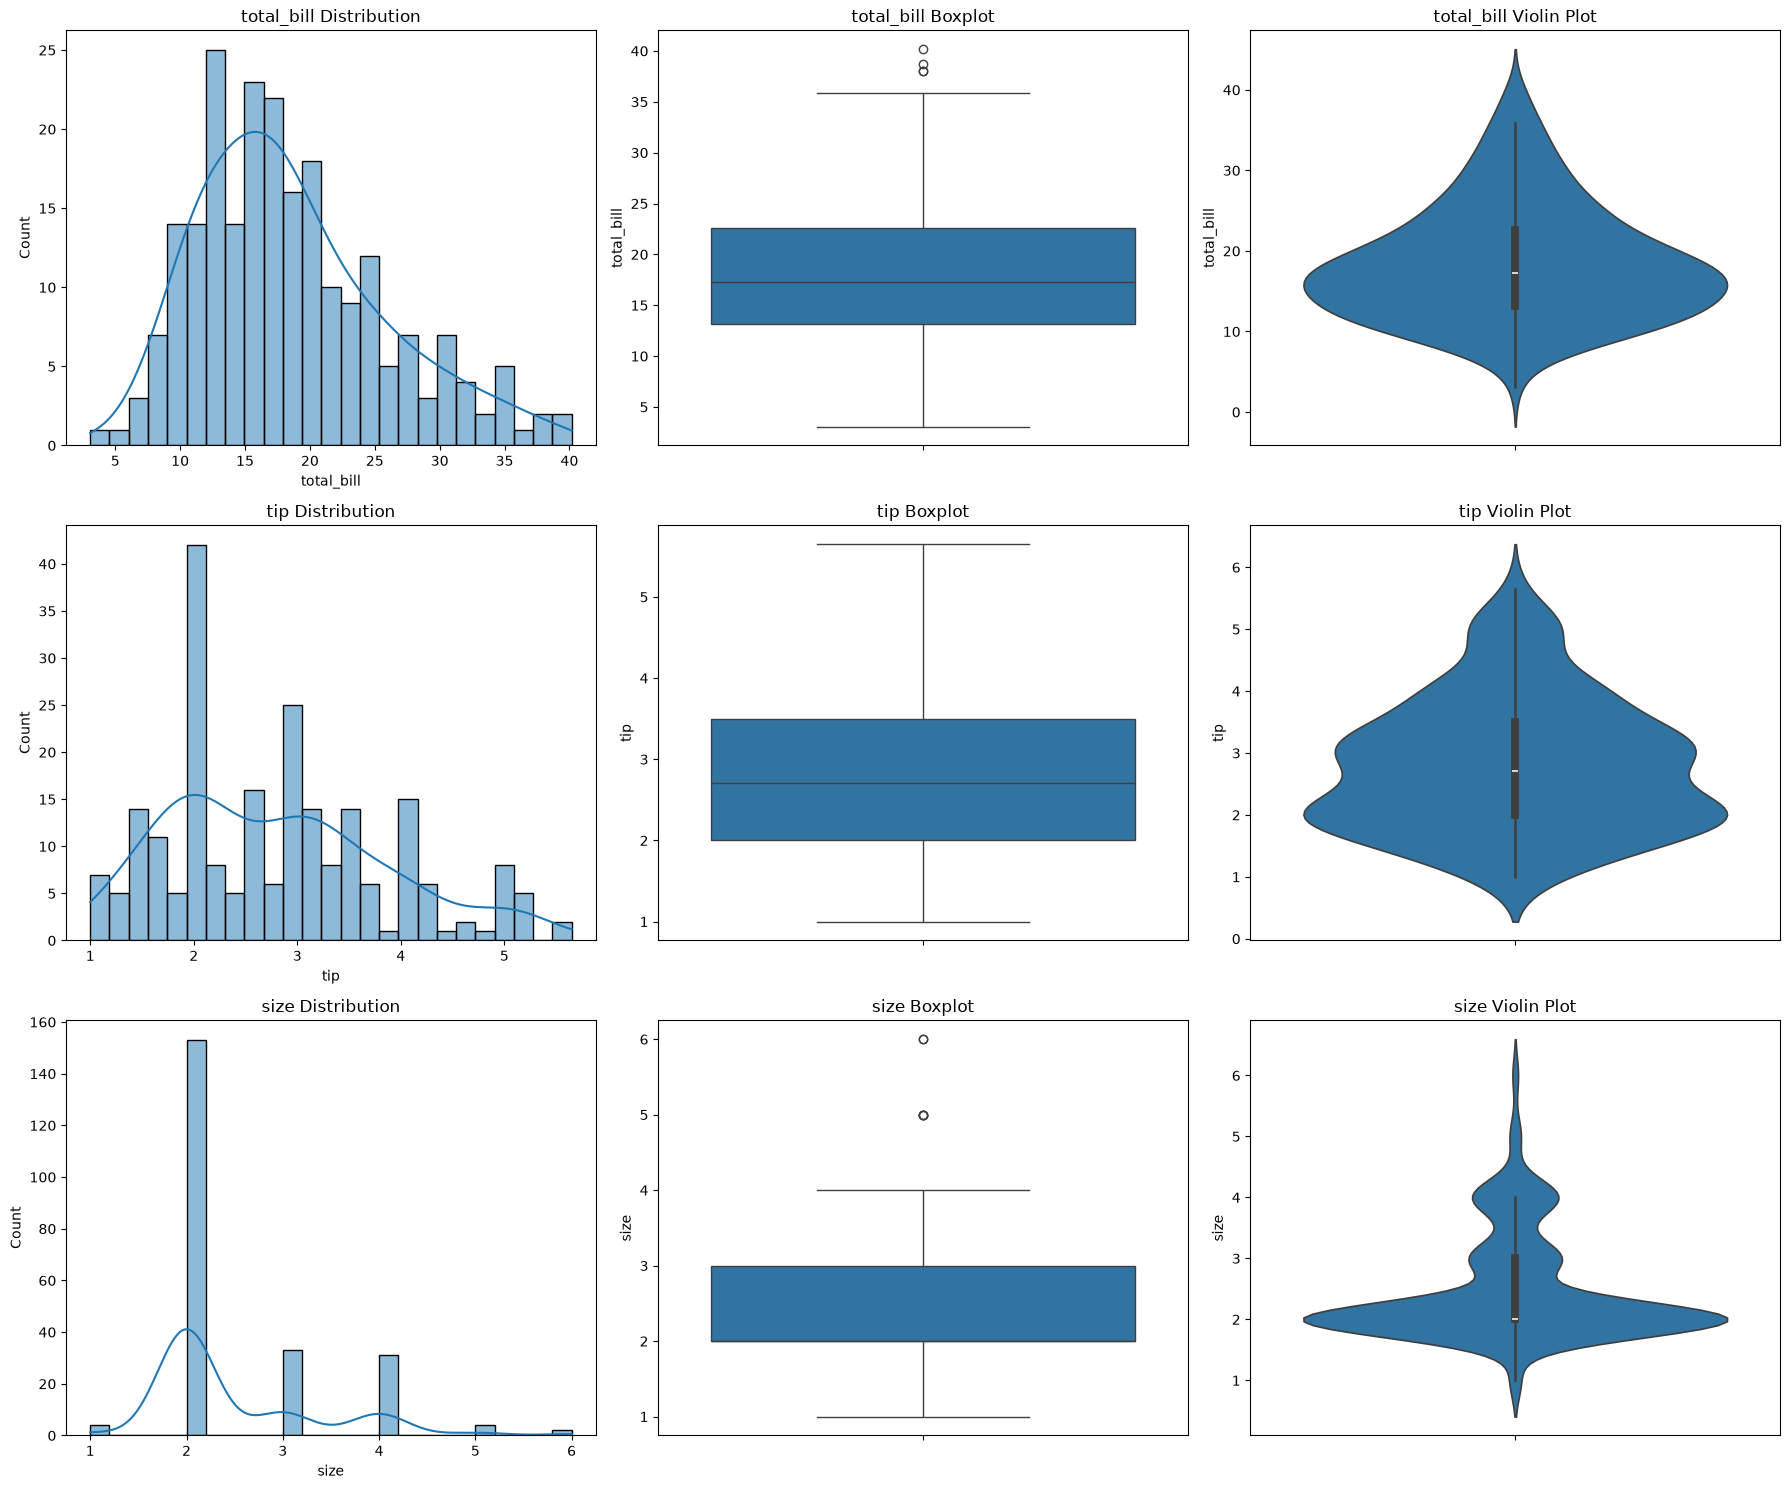

In [19]:
# =====================================================
# Univariate Analysis
# =====================================================

numerical_features = ["total_bill", "tip", "size"]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for i, feature in enumerate(numerical_features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        bins=25,
        ax=axes[i,0]
    )
    axes[i,0].set_title(f"{feature} Distribution")

    sns.boxplot(
        data=df,
        y=feature,
        ax=axes[i,1]
    )
    axes[i,1].set_title(f"{feature} Boxplot")

    sns.violinplot(
        data=df,
        y=feature,
        ax=axes[i,2]
    )
    axes[i,2].set_title(f"{feature} Violin Plot")

plt.tight_layout()
plt.show()

# Target Variable Analysis

Since the objective is to predict the tip amount, understanding its distribution and its relationship with the other numerical variables is essential before training regression models.

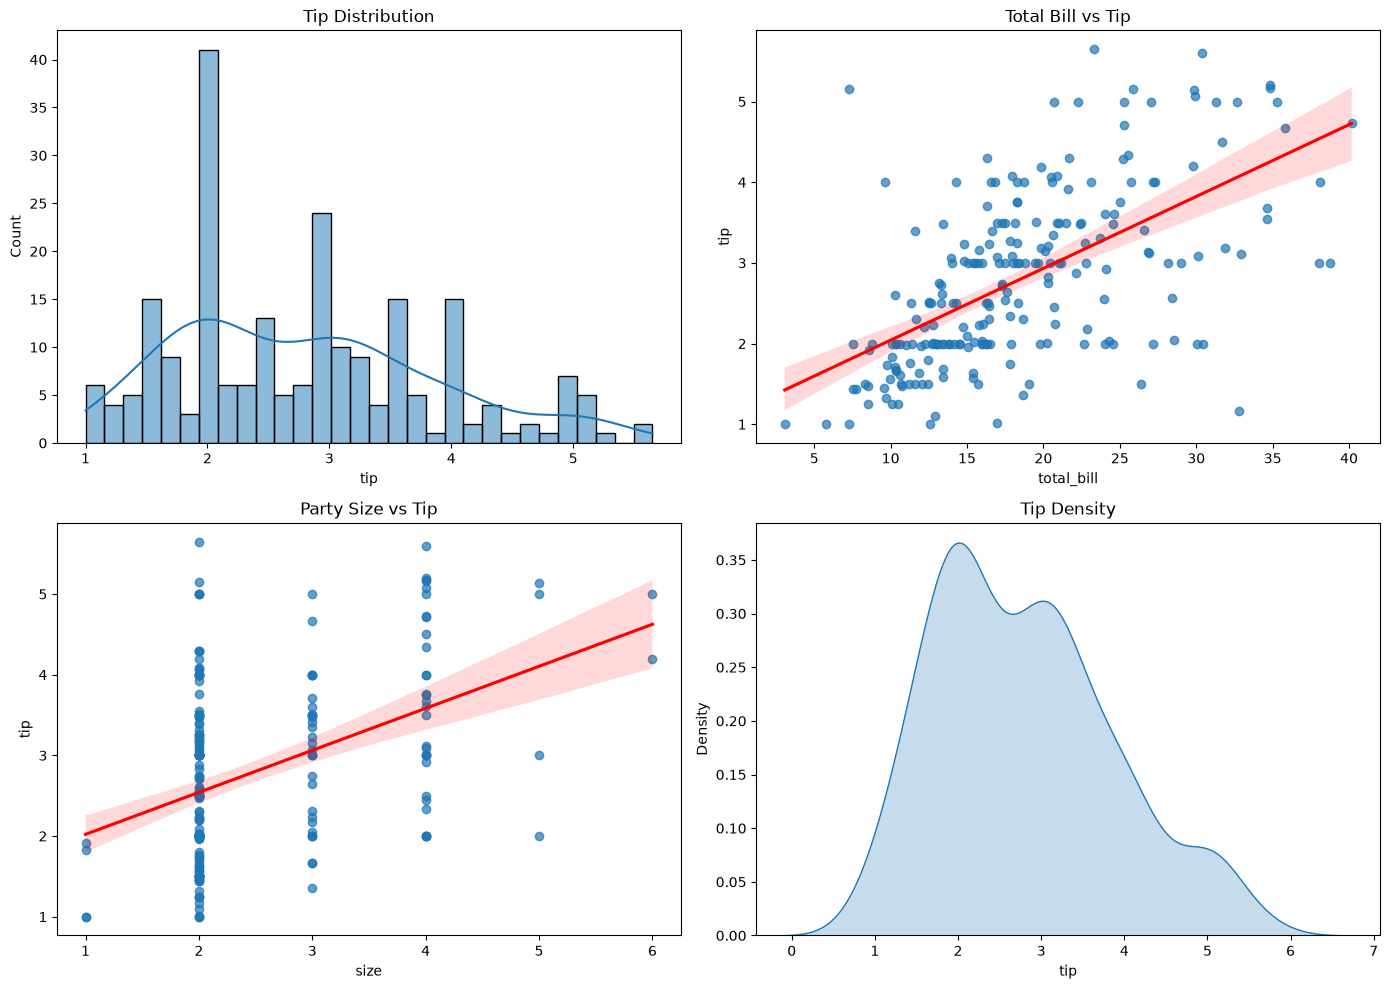

In [20]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.histplot(
    data=df,
    x="tip",
    kde=True,
    bins=30,
    ax=axes[0,0]
)

axes[0,0].set_title("Tip Distribution")

sns.regplot(
    data=df,
    x="total_bill",
    y="tip",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"red"},
    ax=axes[0,1]
)

axes[0,1].set_title("Total Bill vs Tip")

sns.regplot(
    data=df,
    x="size",
    y="tip",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"red"},
    ax=axes[1,0]
)

axes[1,0].set_title("Party Size vs Tip")

sns.kdeplot(
    data=df,
    x="tip",
    fill=True,
    ax=axes[1,1]
)

axes[1,1].set_title("Tip Density")

plt.tight_layout()
plt.show()

# Categorical Feature Analysis

The following visualizations examine how categorical variables influence customer tipping behavior.

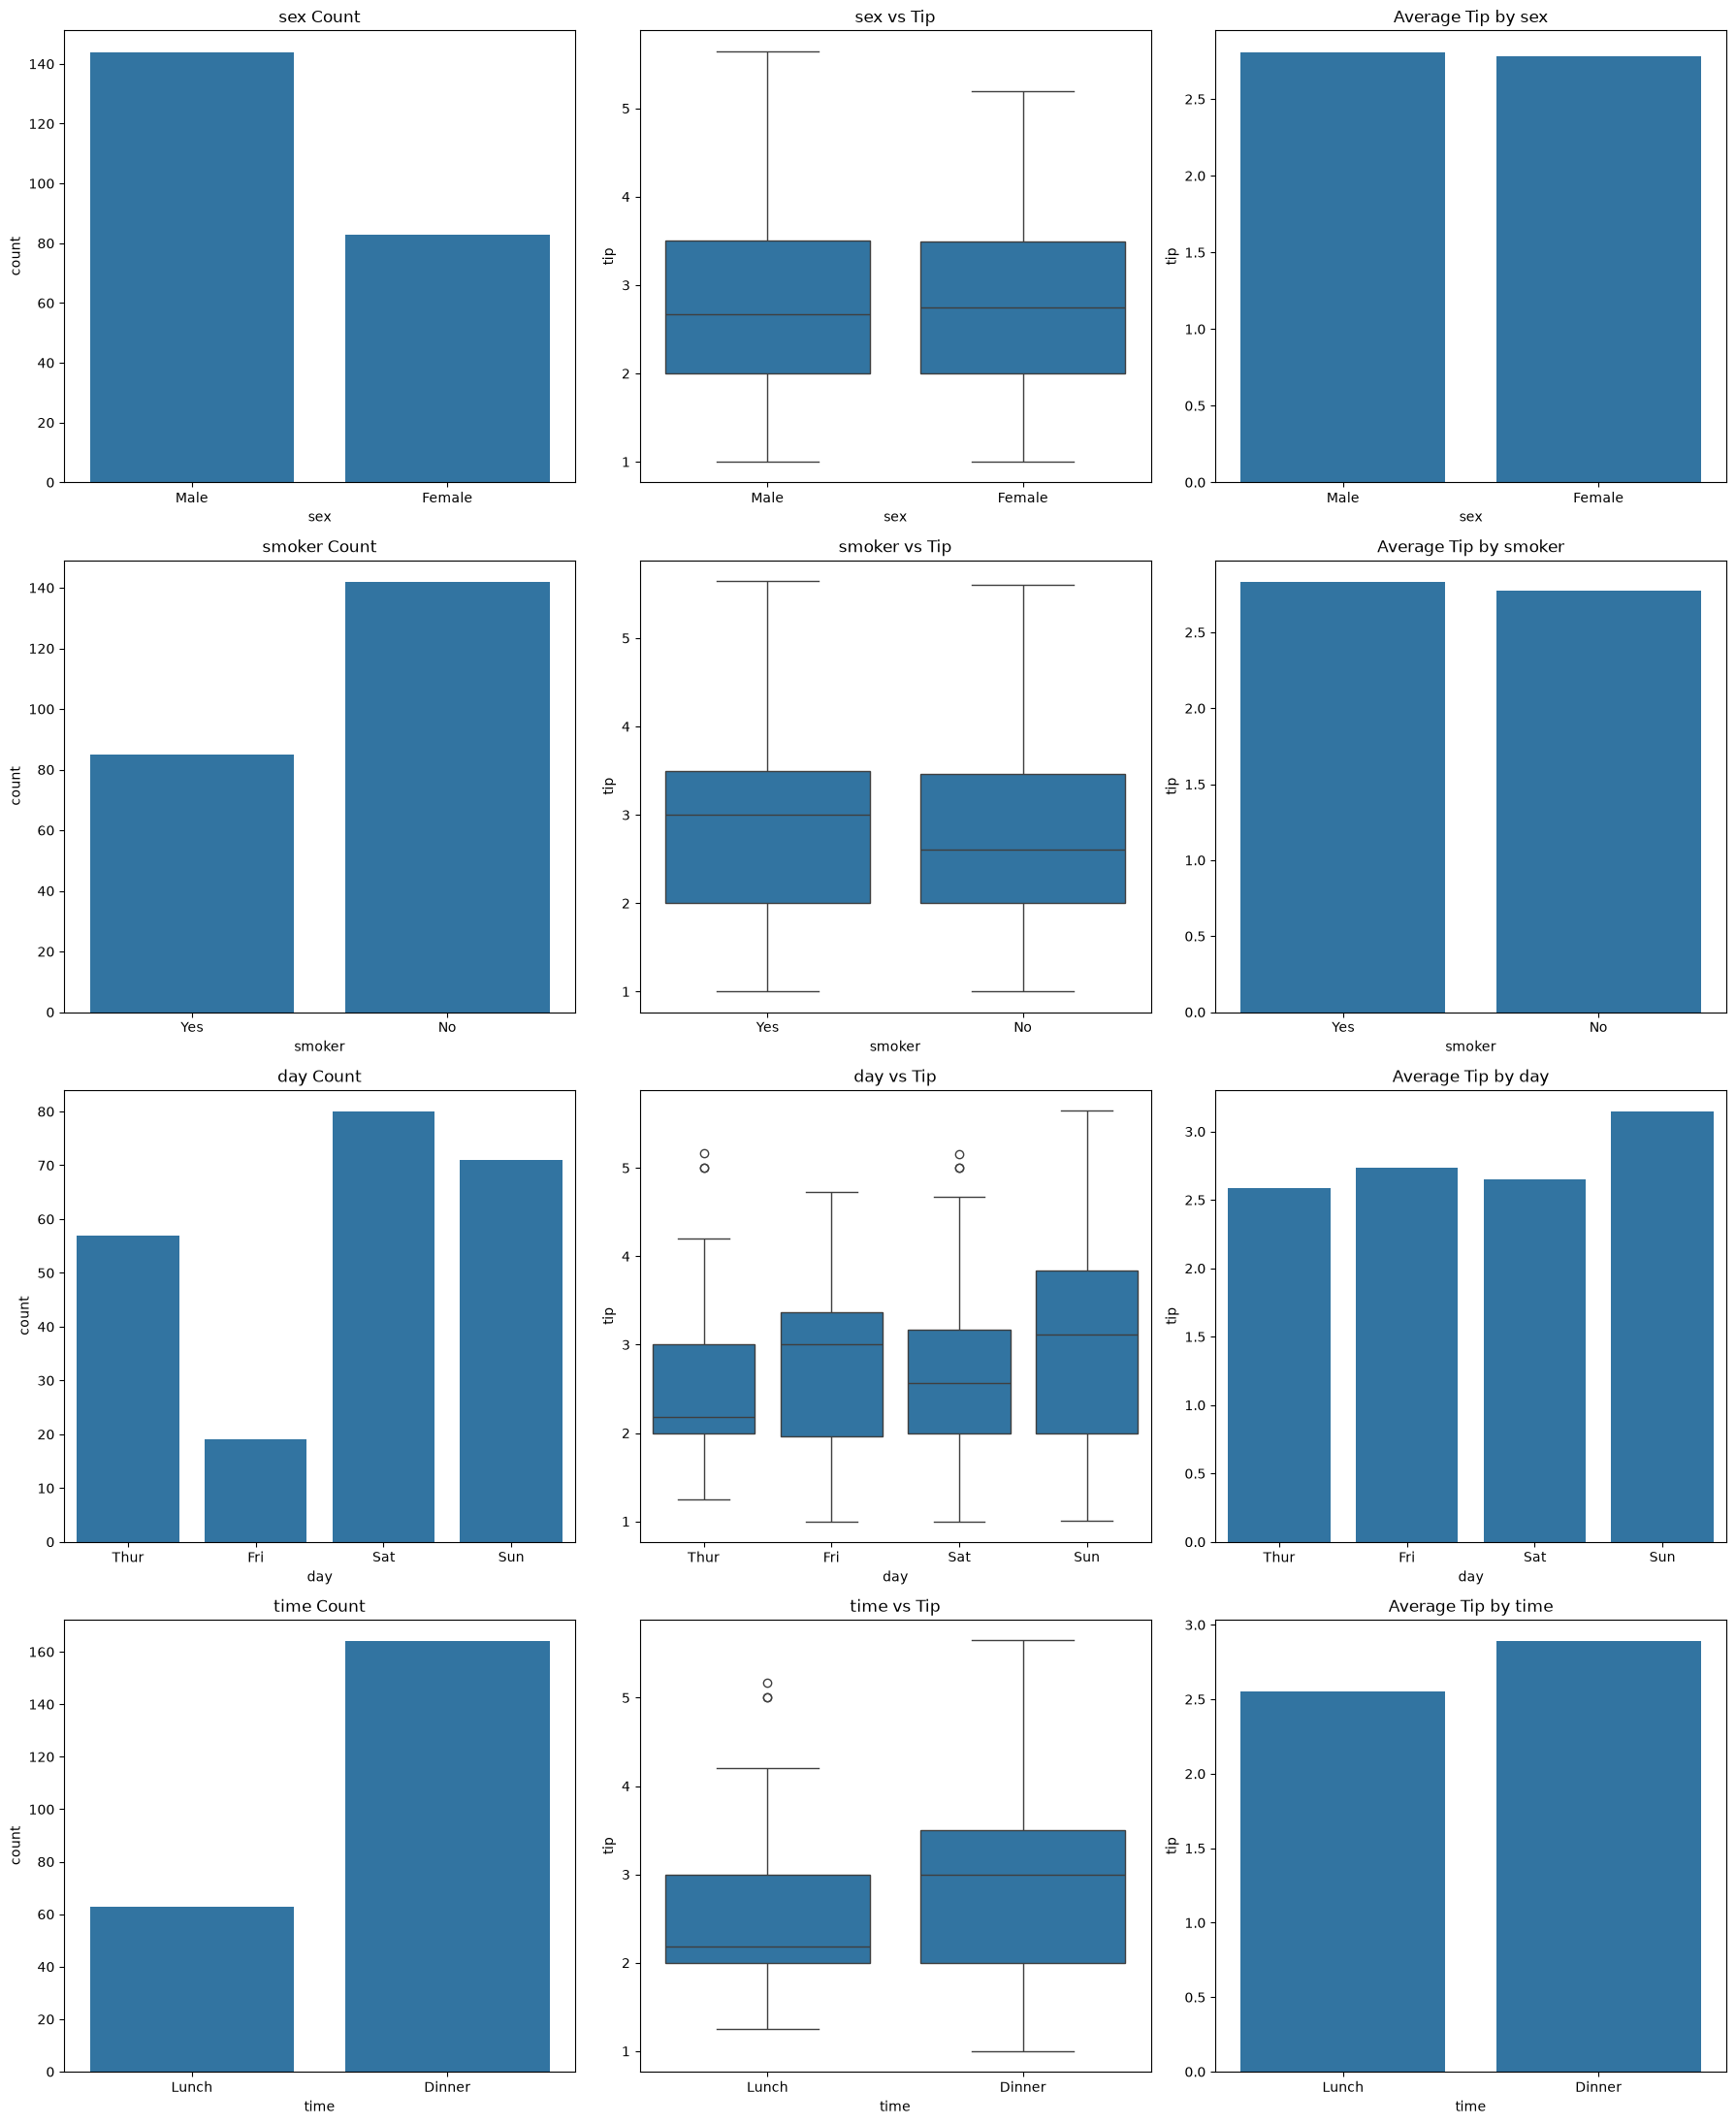

In [21]:
categorical_features = ["sex","smoker","day","time"]

fig, axes = plt.subplots(4,3, figsize=(18,22))

for i, feature in enumerate(categorical_features):

    sns.countplot(
        data=df,
        x=feature,
        ax=axes[i,0]
    )

    axes[i,0].set_title(f"{feature} Count")

    sns.boxplot(
        data=df,
        x=feature,
        y="tip",
        ax=axes[i,1]
    )

    axes[i,1].set_title(f"{feature} vs Tip")

    sns.barplot(
        data=df,
        x=feature,
        y="tip",
        estimator="mean",
        errorbar=None,
        ax=axes[i,2]
    )

    axes[i,2].set_title(f"Average Tip by {feature}")

plt.tight_layout()
plt.show()

# Relationship Analysis

Understanding interactions between numerical variables helps identify strong predictors and multicollinearity before model development.

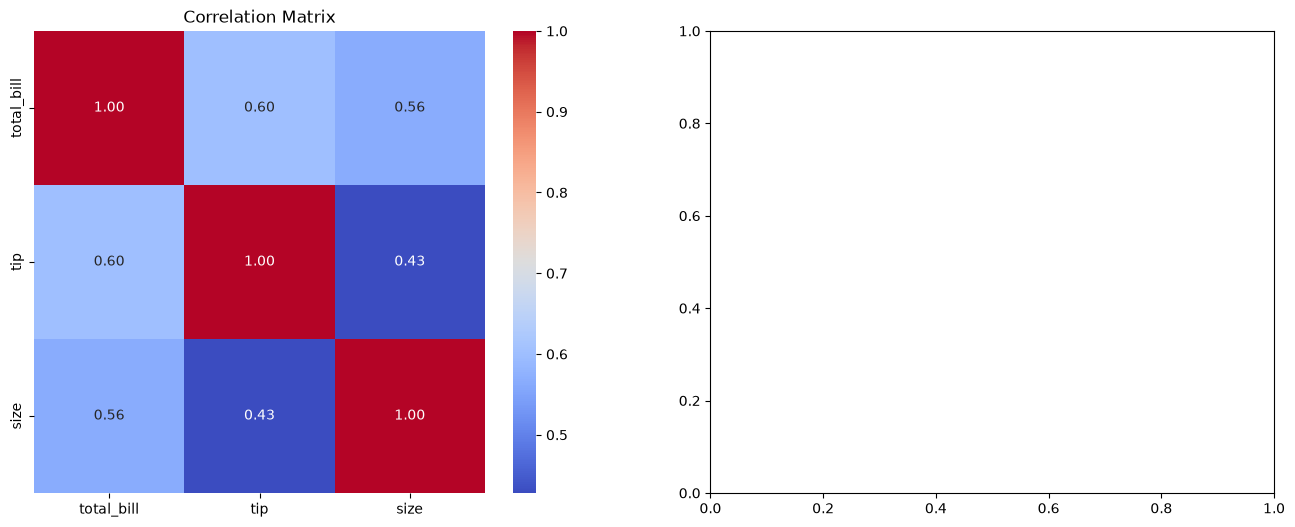

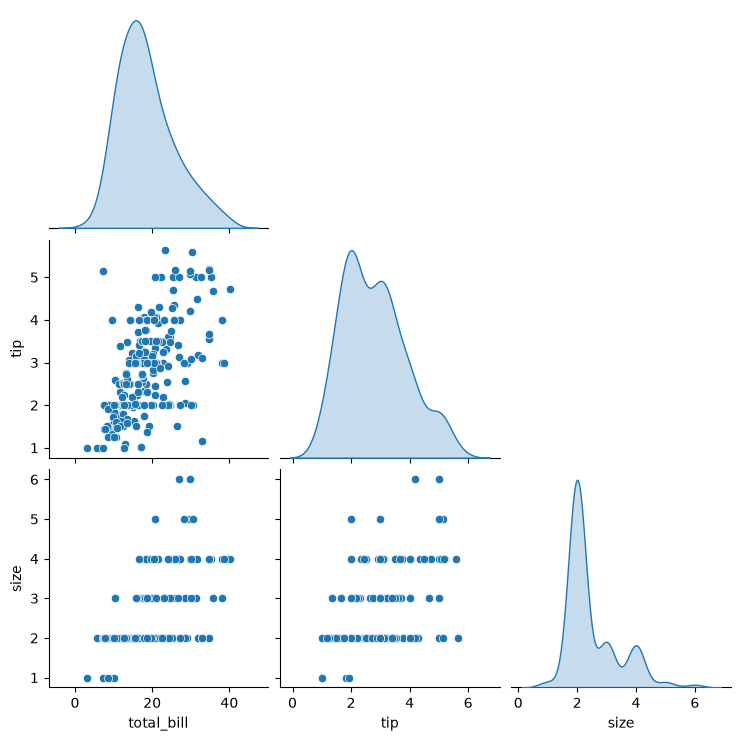

In [22]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0]
)

axes[0].set_title("Correlation Matrix")

sns.pairplot(
    df,
    corner=True,
    diag_kind="kde"
)

plt.show()

# Feature Engineering & Data Preprocessing

Before training the regression models, categorical variables must be encoded while numerical variables are passed unchanged.

A preprocessing pipeline is used to ensure that the same transformations are consistently applied during both training and prediction, making the final model ready for deployment.

In [23]:
# ============================
# Features & Target
# ============================

X = df.drop("tip", axis=1)
y = df["tip"]

categorical_features = X.select_dtypes(include="category").columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# ============================
# Preprocessor
# ============================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

# ============================
# Train/Test Split
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 181
Testing Samples  : 46


# Linear Regression

Linear Regression serves as the baseline model for this project.

It assumes a linear relationship between the independent variables and the target variable. Although restaurant tipping behavior may contain non-linear patterns, Linear Regression provides an important benchmark for comparing more advanced machine learning algorithms.

The model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

,Metric,Value
0,MAE,0.686557
1,MSE,0.754661
2,RMSE,0.868712
3,R² Score,0.324935


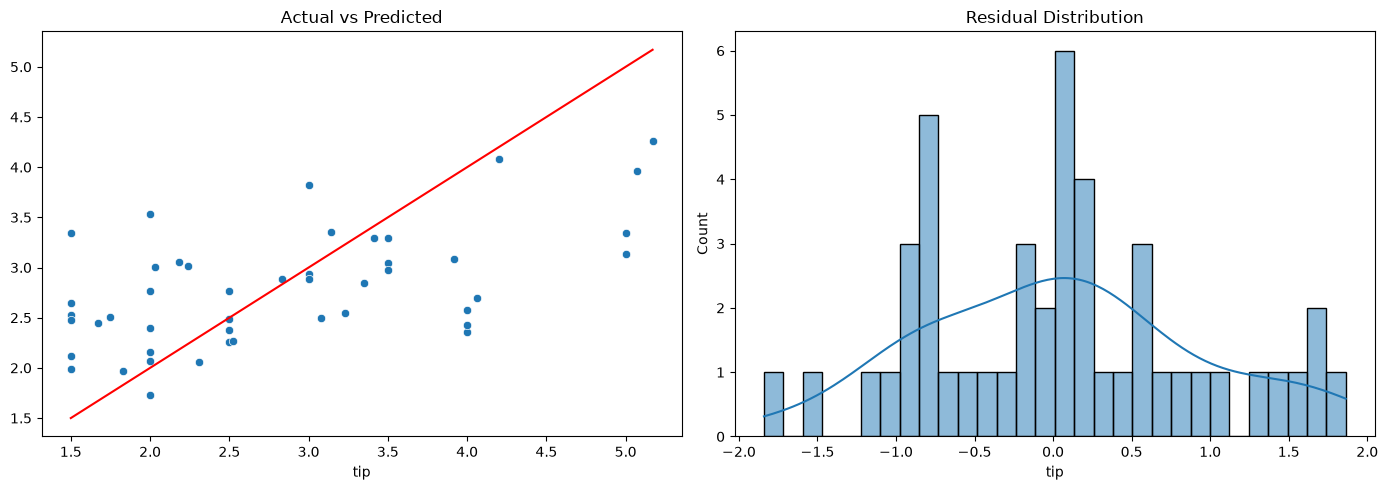

In [24]:
# ============================================================
# Linear Regression
# ============================================================

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

linear_results = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[linear_mae,linear_mse,linear_rmse,linear_r2]
})

display(linear_results)

fig, axes = plt.subplots(1,2,figsize=(14,5))

sns.scatterplot(
    x=y_test,
    y=linear_pred,
    ax=axes[0]
)

axes[0].plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

axes[0].set_title("Actual vs Predicted")

residuals = y_test-linear_pred

sns.histplot(
    residuals,
    kde=True,
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# Decision Tree Regressor

Decision Trees can capture complex non-linear relationships without assuming any specific mathematical form.

However, a fully grown decision tree often overfits the training data. Therefore, hyperparameter tuning is performed using GridSearchCV to identify a more generalized model.

{'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}


,Metric,Value
0,MAE,0.700394
1,MSE,0.874560
2,RMSE,0.935179
3,R² Score,0.217682


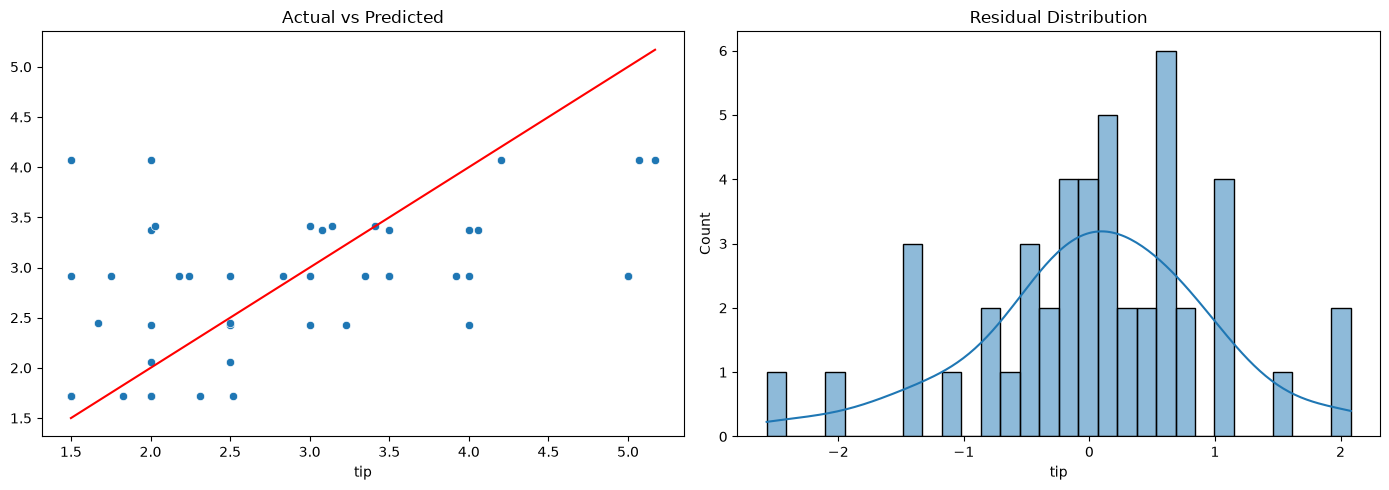

In [25]:
# ============================================================
# Decision Tree Regression
# ============================================================

tree_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",DecisionTreeRegressor(random_state=42))
])

tree_parameters = {
    "model__max_depth":[3,5,7,10,None],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4]
}

tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

tree_grid.fit(X_train,y_train)

best_tree = tree_grid.best_estimator_

tree_pred = best_tree.predict(X_test)

tree_mae = mean_absolute_error(y_test,tree_pred)
tree_mse = mean_squared_error(y_test,tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test,tree_pred)

print(tree_grid.best_params_)

tree_results = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[tree_mae,tree_mse,tree_rmse,tree_r2]
})

display(tree_results)

fig,axes=plt.subplots(1,2,figsize=(14,5))

sns.scatterplot(
    x=y_test,
    y=tree_pred,
    ax=axes[0]
)

axes[0].plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

axes[0].set_title("Actual vs Predicted")

sns.histplot(
    y_test-tree_pred,
    kde=True,
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# Random Forest Regressor

Random Forest combines multiple decision trees into an ensemble model.

By averaging the predictions from many trees, Random Forest generally produces better generalization performance, lower variance, and improved prediction accuracy compared to a single Decision Tree.

Hyperparameter optimization is performed to identify the best-performing configuration.

{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}


,Metric,Value
0,MAE,0.705719
1,MSE,0.799532
2,RMSE,0.894166
3,R² Score,0.284797


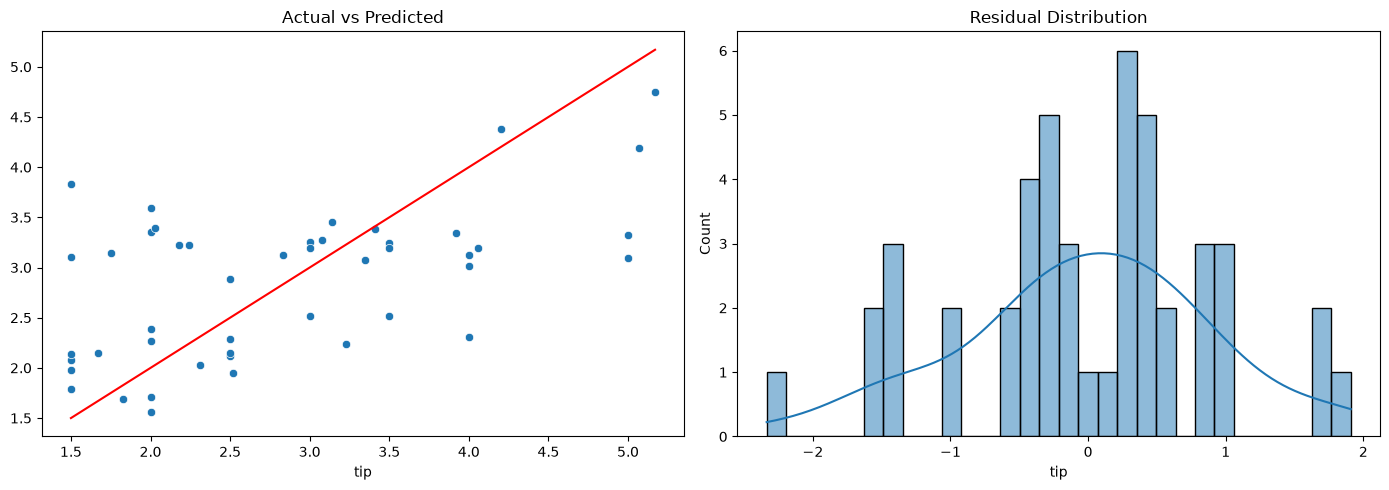

In [26]:
# ============================================================
# Random Forest Regression
# ============================================================

rf_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(random_state=42))
])

rf_parameters = {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[5,10,None],
    "model__min_samples_split":[2,5],
    "model__min_samples_leaf":[1,2]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train,y_train)

best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test,rf_pred)
rf_mse = mean_squared_error(y_test,rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test,rf_pred)

print(rf_grid.best_params_)

rf_results = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[rf_mae,rf_mse,rf_rmse,rf_r2]
})

display(rf_results)

fig,axes=plt.subplots(1,2,figsize=(14,5))

sns.scatterplot(
    x=y_test,
    y=rf_pred,
    ax=axes[0]
)

axes[0].plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

axes[0].set_title("Actual vs Predicted")

sns.histplot(
    y_test-rf_pred,
    kde=True,
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is one of the most powerful ensemble learning algorithms for regression tasks.

Unlike bagging methods such as Random Forest, XGBoost builds trees sequentially, where each new tree attempts to correct the prediction errors of the previous trees.

Its ability to model complex nonlinear relationships while controlling overfitting often leads to superior predictive performance.

Hyperparameter tuning is performed using GridSearchCV to identify the optimal model configuration.

{'model__colsample_bytree': 1, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1}


,Metric,Value
0,MAE,0.677453
1,MSE,0.790395
2,RMSE,0.889042
3,R² Score,0.292970


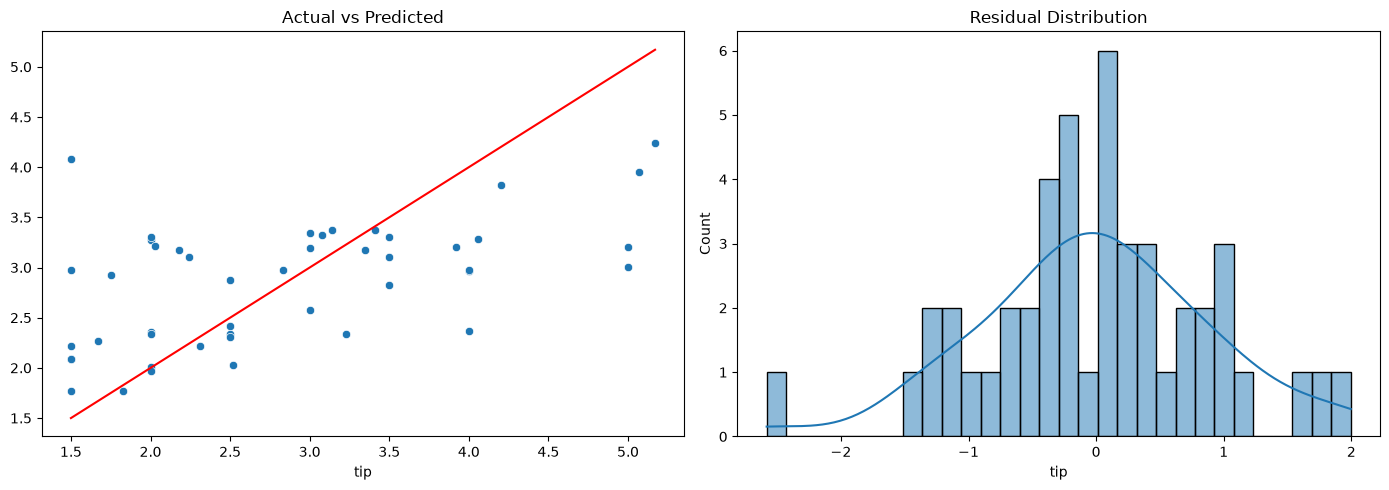

In [27]:
# ==========================================================
# XGBoost Regressor
# ==========================================================

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators":[100,200,300],
    "model__learning_rate":[0.01,0.05,0.1],
    "model__max_depth":[3,5,7],
    "model__subsample":[0.8,1],
    "model__colsample_bytree":[0.8,1]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train,y_train)

best_xgb = xgb_grid.best_estimator_

xgb_pred = best_xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test,xgb_pred)
xgb_mse = mean_squared_error(y_test,xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test,xgb_pred)

print(xgb_grid.best_params_)

xgb_results = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[xgb_mae,xgb_mse,xgb_rmse,xgb_r2]
})

display(xgb_results)

fig,axes=plt.subplots(1,2,figsize=(14,5))

sns.scatterplot(
    x=y_test,
    y=xgb_pred,
    ax=axes[0]
)

axes[0].plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

axes[0].set_title("Actual vs Predicted")

sns.histplot(
    y_test-xgb_pred,
    kde=True,
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# Model Comparison

After training all regression models, their performance is compared using multiple evaluation metrics.

Since regression models should minimize prediction errors while maximizing explanatory power, the comparison considers:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The best model will be selected according to the highest R² Score while maintaining the lowest prediction errors.

In [28]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE":[
        linear_mae,
        tree_mae,
        rf_mae,
        xgb_mae
    ],

    "MSE":[
        linear_mse,
        tree_mse,
        rf_mse,
        xgb_mse
    ],

    "RMSE":[
        linear_rmse,
        tree_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2 Score":[
        linear_r2,
        tree_r2,
        rf_r2,
        xgb_r2
    ]

})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

display(comparison)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.686557,0.754661,0.868712,0.324935
1,XGBoost,0.677453,0.790395,0.889042,0.292970
2,Random Forest,0.705719,0.799532,0.894166,0.284797
3,Decision Tree,0.700394,0.874560,0.935179,0.217682
